<a href="https://colab.research.google.com/github/AleCicee/Progetto-Difesa-Italia-Analisi/blob/main/Progetto8_Analisi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Progetto 8: Ripudio della guerra, spesa per la difesa e commercio di armamenti

**Obiettivi del progetto:**
- Descrivere l'andamento della spesa per la difesa (Italia e confronto NATO/UE).
- Scomporre la spesa (personale / esercizio / investimenti).
- Analizzare i dati ufficiali su autorizzazioni e operazioni di export di armamenti (Legge 185/90).
- Produrre un report replicabile con analisi dati, regressione e riflessioni conclusive.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Reperimento dati e Indicatori Ufficiali

I dati utilizzati provengono dalle seguenti fonti ufficiali:
1. **SIPRI (Stockholm International Peace Research Institute)**: Spesa militare in percentuale sul PIL e in valuta costante.
   *Motivazione*: È l'istituto di riferimento globale per i dati aperti sulle spese militari.
2. **NATO - Defence Expenditure Data (2014-2025)**: Dati dettagliati aggregati sui paesi NATO e suddivisione per categoria (personale, equipaggiamenti, etc.).
   *Motivazione*: Permette di analizzare nel dettaglio l'allocazione della spesa per i paesi dell'Alleanza.
3. **Relazione Al Parlamento (Legge 185/90)**: Esportazioni e autorizzazioni per materiali di armamento.
   *Motivazione*: Fonte ufficiale governativa italiana sulle esportazioni di armamenti, vincolata alla legge sul ripudio della guerra.

In [ ]:
# Importazione delle librerie necessarie
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import linregress

# Impostazioni di visualizzazione
%matplotlib inline
sns.set_theme(style="whitegrid")

## 2. Acquisizione Dati

In [ ]:
# Percorsi ai dataset raw
path_sipri_gdp = '/content/drive/MyDrive/Fonti progetto guerra | TIMIS-CICERCHIA/Military expenditure by country as a share of GDP/Share of GDP.csv'
path_nato_table3 = '/content/drive/MyDrive/Fonti progetto guerra | TIMIS-CICERCHIA/Defence Expenditure of NATO Countries 2014-2025/Table 3.csv'      # Spesa difesa % PIL
path_nato_table8a = '/content/drive/MyDrive/Fonti progetto guerra | TIMIS-CICERCHIA/Defence Expenditure of NATO Countries 2014-2025/Table 8a.csv'    # Equipment (% spesa)
path_nato_table8b = '/content/drive/MyDrive/Fonti progetto guerra | TIMIS-CICERCHIA/Defence Expenditure of NATO Countries 2014-2025/Table 8b.csv'    # Personnel (% spesa)
path_export_armi = '/content/drive/MyDrive/Fonti progetto guerra | TIMIS-CICERCHIA/Commercio di Armamenti Legge 185 90/Commercio di Armamenti Legge 185 90.csv'


def find_header_row(file_path, header_prefix='Recipient,Supplier'):
    """Trova la riga che contiene l'intestazione reale del CSV export."""
    with open(file_path, 'r', encoding='cp1252', errors='replace') as f:
        for i, line in enumerate(f):
            if line.startswith(header_prefix):
                return i
    raise ValueError(f"Intestazione non trovata in {file_path}")


# Lettura dei dati
try:
    df_sipri_gdp = pd.read_csv(path_sipri_gdp, skiprows=5, encoding='cp1252')
    df_nato_share = pd.read_csv(path_nato_table3, skiprows=3, encoding='cp1252')
    df_nato_equip = pd.read_csv(path_nato_table8a, skiprows=3, encoding='cp1252')
    df_nato_personnel = pd.read_csv(path_nato_table8b, skiprows=3, encoding='cp1252')

    export_header_row = find_header_row(path_export_armi)
    df_export_armi = pd.read_csv(path_export_armi, skiprows=export_header_row, encoding='cp1252')

    print('Dati acquisiti con successo!')
    print(f'Riga intestazione export trovata a indice: {export_header_row}')
    print(f'Shape SIPRI: {df_sipri_gdp.shape}')
    print(f'Shape NATO Table 3: {df_nato_share.shape}')
    print(f'Shape NATO Table 8a: {df_nato_equip.shape}')
    print(f'Shape NATO Table 8b: {df_nato_personnel.shape}')
    print(f'Shape Export: {df_export_armi.shape}')
except Exception as e:
    print(f"Errore durante l'acquisizione dei dati: {e}")

Dati acquisiti con successo!
Riga intestazione export trovata a indice: 11
Shape SIPRI: (193, 78)
Shape NATO Table 3: (69, 13)
Shape NATO Table 8a: (65, 13)
Shape NATO Table 8b: (65, 13)
Shape Export: (993, 16)


## 3. Pulizia e Trasformazioni

A questo punto, ispezioniamo i dataframe, rimuoviamo valori nulli inutili, sistemiamo l'intestazione e prepariamo una versione "clean".

In [ ]:
# Funzione generica per mostrare un riepilogo dati
def data_summary(df, name="DataFrame"):
    print(f"--- Riepilogo {name} ---")
    print(df.info())
    display(df.head())

# data_summary(df_sipri_gdp, "SIPRI Share of GDP")
# data_summary(df_export_armi, "Export Armi (Legge 185/90)")

In [ ]:
# --- PULIZIA DATI ---

# 1) SIPRI: formato largo -> lungo
# Rimuoviamo righe aggregate/regioni che non hanno dati utili e teniamo solo colonne anno.
df_sipri_clean = df_sipri_gdp.copy()
df_sipri_clean.columns = [str(c).strip() for c in df_sipri_clean.columns]

if 'Notes' in df_sipri_clean.columns:
    df_sipri_clean = df_sipri_clean.drop(columns=['Notes'])

df_sipri_clean['Country'] = df_sipri_clean['Country'].astype(str).str.strip()
df_sipri_clean = df_sipri_clean[df_sipri_clean['Country'].notna()]

year_cols_sipri = [c for c in df_sipri_clean.columns if c.isdigit()]
df_sipri_clean = df_sipri_clean[['Country'] + year_cols_sipri]
df_sipri_clean = df_sipri_clean.melt(id_vars=['Country'], var_name='Year', value_name='Share_of_GDP')

df_sipri_clean['Share_of_GDP'] = (
    df_sipri_clean['Share_of_GDP']
    .replace(['...', 'xxx', '. .', 'nan'], np.nan)
    .astype(str)
    .str.replace('%', '', regex=False)
)
df_sipri_clean['Share_of_GDP'] = pd.to_numeric(df_sipri_clean['Share_of_GDP'], errors='coerce') / 100
df_sipri_clean['Year'] = pd.to_numeric(df_sipri_clean['Year'], errors='coerce')
df_sipri_clean = df_sipri_clean.dropna(subset=['Year', 'Share_of_GDP'])

# Serie Italia da SIPRI
italy_sipri = (
    df_sipri_clean[df_sipri_clean['Country'].eq('Italy')][['Year', 'Share_of_GDP']]
    .sort_values('Year')
    .drop_duplicates(subset=['Year'])
    .reset_index(drop=True)
)

# 2) NATO Table 3: spesa difesa % PIL
def clean_nato_table(df_raw, value_name):
    df = df_raw.copy()
    df.columns = [str(c).strip() for c in df.columns]
    first_col = df.columns[0]
    df = df.rename(columns={first_col: 'Country'})
    df['Country'] = df['Country'].astype(str).str.strip()
    year_cols = [c for c in df.columns if str(c).replace('e', '').isdigit()]
    df = df[['Country'] + year_cols]
    df = df.melt(id_vars=['Country'], var_name='Year', value_name=value_name)
    df['Year'] = df['Year'].astype(str).str.replace('e', '', regex=False)
    df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
    df[value_name] = pd.to_numeric(df[value_name], errors='coerce')
    df = df.dropna(subset=['Year', value_name])
    return df

nato_share_clean = clean_nato_table(df_nato_share, 'NATO_Share_of_GDP')
italy_nato_share = (
    nato_share_clean[nato_share_clean['Country'].eq('Italy')][['Year', 'NATO_Share_of_GDP']]
    .sort_values('Year')
    .drop_duplicates(subset=['Year'], keep='first')
    .reset_index(drop=True)
)

# 3) NATO 8a/8b: scomposizione % della spesa (equipment e personnel)
nato_equip_clean = clean_nato_table(df_nato_equip, 'Equipment_pct')
nato_personnel_clean = clean_nato_table(df_nato_personnel, 'Personnel_pct')

italy_comp = (
    nato_equip_clean[nato_equip_clean['Country'].eq('Italy')][['Year', 'Equipment_pct']]
    .sort_values('Year')
    .drop_duplicates(subset=['Year'], keep='first')
    .merge(
        nato_personnel_clean[nato_personnel_clean['Country'].eq('Italy')][['Year', 'Personnel_pct']]
        .sort_values('Year')
        .drop_duplicates(subset=['Year'], keep='first'),
        on='Year',
        how='inner'
    )
)
italy_comp['Other_pct'] = 100 - italy_comp['Equipment_pct'] - italy_comp['Personnel_pct']

# 4) Export armamenti: trend annuale per Year of order e TIV delivered
export_cols = [c.strip() for c in df_export_armi.columns]
df_export_clean = df_export_armi.copy()
df_export_clean.columns = export_cols

for c in ['Year of order', 'SIPRI TIV of delivered weapons']:
    df_export_clean[c] = pd.to_numeric(df_export_clean[c], errors='coerce')

export_yearly = (
    df_export_clean
    .dropna(subset=['Year of order', 'SIPRI TIV of delivered weapons'])
    .groupby('Year of order', as_index=False)['SIPRI TIV of delivered weapons']
    .sum()
    .rename(columns={'Year of order': 'Year', 'SIPRI TIV of delivered weapons': 'Export_TIV_Mln'})
    .sort_values('Year')
)

# Salvataggio dataset clean
italy_sipri.to_csv('/content/drive/MyDrive/Fonti progetto guerra | TIMIS-CICERCHIA/Military expenditure by country as a share of GDP/Italy_share_gdp_clean.csv', index=False)
italy_nato_share.to_csv('/content/drive/MyDrive/Fonti progetto guerra | TIMIS-CICERCHIA/Defence Expenditure of NATO Countries 2014-2025/Italy_nato_share_gdp_clean.csv', index=False)
italy_comp.to_csv('/content/drive/MyDrive/Fonti progetto guerra | TIMIS-CICERCHIA/Defence Expenditure of NATO Countries 2014-2025/Italy_spending_composition_clean.csv', index=False)
export_yearly.to_csv('/content/drive/MyDrive/Fonti progetto guerra | TIMIS-CICERCHIA/Commercio di Armamenti Legge 185 90/Italy_export_tiv_yearly_clean.csv', index=False)

print('Pulizia completata e file clean salvati.')
print('Rows Italy SIPRI:', len(italy_sipri))
print('Rows Italy NATO share:', len(italy_nato_share))
print('Rows Italy composition:', len(italy_comp))
print('Rows Export yearly:', len(export_yearly))

Pulizia completata e file clean salvati.
Rows Italy SIPRI: 74
Rows Italy NATO share: 12
Rows Italy composition: 12
Rows Export yearly: 76


## 4. Analisi
### 4.1. Andamento spesa Italia vs NATO/UE
L'obiettivo europeo e NATO è fissato a circa il 2% del PIL. Analizziamo quanto spende l'Italia.

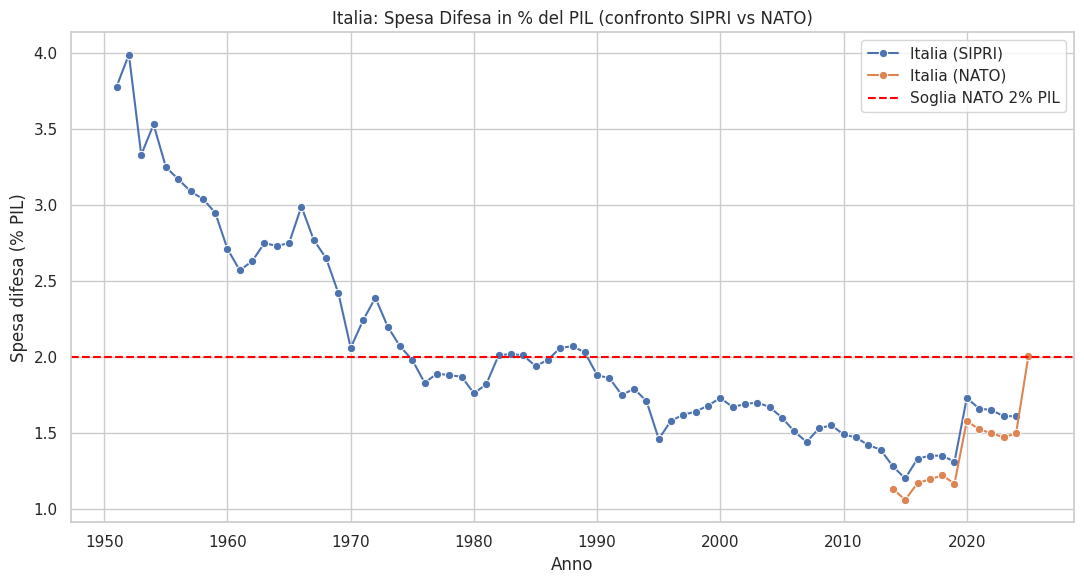

In [ ]:
# Grafico 1: Andamento spesa Italia (% PIL), confronto SIPRI vs NATO e soglia 2%
plot_sipri = italy_sipri.copy()
plot_sipri['SIPRI_pct_GDP'] = plot_sipri['Share_of_GDP'] * 100

plt.figure(figsize=(11, 6))

sns.lineplot(data=plot_sipri, x='Year', y='SIPRI_pct_GDP', marker='o', label='Italia (SIPRI)')
sns.lineplot(data=italy_nato_share, x='Year', y='NATO_Share_of_GDP', marker='o', label='Italia (NATO)')

plt.axhline(y=2.0, color='red', linestyle='--', label='Soglia NATO 2% PIL')
plt.title('Italia: Spesa Difesa in % del PIL (confronto SIPRI vs NATO)')
plt.xlabel('Anno')
plt.ylabel('Spesa difesa (% PIL)')
plt.legend()
plt.tight_layout()
plt.show()

### Analisi del grafico 1 (Spesa difesa % PIL: Italia SIPRI vs NATO)

Il grafico mostra tre elementi chiave:

1. **Trend storico di lungo periodo (SIPRI)**: dal secondo dopoguerra agli anni recenti, la quota di PIL italiana dedicata alla difesa segue una tendenza complessivamente decrescente di lungo periodo, con fasi di assestamento.
2. **Fase recente (NATO 2014-2025)**: nella finestra più attuale la serie NATO indica una dinamica crescente, con avvicinamento progressivo alla soglia del 2% e un salto forte nell'ultimo anno disponibile.
3. **Confrontabilità tra fonti**: SIPRI e NATO sono allineate nella direzione generale del fenomeno, ma possono differire nei livelli puntuali per metodologia e perimetro contabile.

Lettura da data analyst:
- il messaggio non è solo "quanto spendiamo", ma **come cambia il rapporto con il PIL nel tempo**;
- la convergenza verso il 2% appare recente e non uniforme;
- per policy analysis conviene sempre accompagnare la % PIL con il dato in valori assoluti reali (inflazione corretta).

### 4.2. Scomposizione della spesa della difesa
Scomponiamo la spesa in personale, equipaggiamento/investimenti e altre operazioni sulla base dei dati NATO.

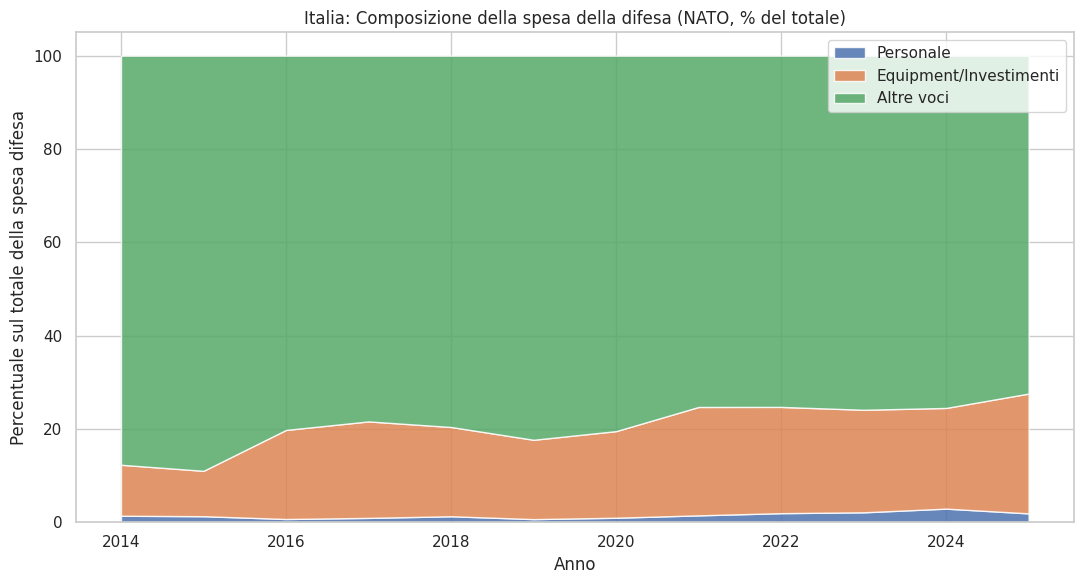

In [ ]:
# Grafico 2: Scomposizione della spesa italiana (personale, equipment, altre voci)
plot_comp = italy_comp.copy().sort_values('Year')

plt.figure(figsize=(11, 6))
plt.stackplot(
    plot_comp['Year'],
    plot_comp['Personnel_pct'],
    plot_comp['Equipment_pct'],
    plot_comp['Other_pct'],
    labels=['Personale', 'Equipment/Investimenti', 'Altre voci'],
    alpha=0.85
)
plt.title('Italia: Composizione della spesa della difesa (NATO, % del totale)')
plt.xlabel('Anno')
plt.ylabel('Percentuale sul totale della spesa difesa')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

### Analisi del grafico 2 (Composizione della spesa: personale, equipment, altre voci)

Questo grafico evidenzia la **struttura interna** della spesa militare, non solo il suo livello totale.

1. **Peso del personale**: rimane una componente molto rilevante e relativamente stabile, segnalando rigidità strutturale del bilancio difesa.
2. **Quota equipment/investimenti**: cresce in più anni recenti, indicando una possibile riallocazione verso modernizzazione e capacità tecnologiche.
3. **Altre voci**: la componente residua mostra che una parte consistente della spesa resta destinata a funzioni non riconducibili direttamente a personale o procurement.

Interpretazione operativa:
- se aumenta la spesa totale ma la composizione non cambia, l'effetto sulle capacità può essere limitato;
- la vera discontinuità strategica si osserva quando cresce in modo persistente la quota investimenti;
- la lettura andrebbe completata con benchmark su altri paesi NATO per capire se l'Italia è "in linea" o "in ritardo" nella composizione ottimale.

### 4.3. Export di Armamenti (Legge 185/90)
Analisi delle esportazioni e delle autorizzazioni.

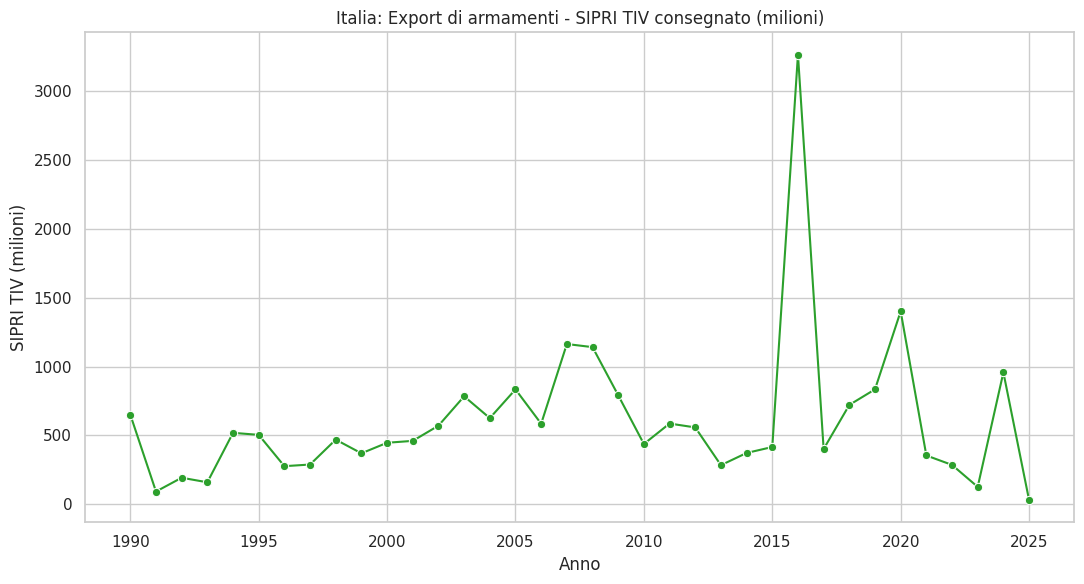

In [ ]:
# Grafico 3: Trend annuale export armamenti italiani (SIPRI TIV, milioni)
plot_export = export_yearly[export_yearly['Year'] >= 1990].copy()

plt.figure(figsize=(11, 6))
sns.lineplot(data=plot_export, x='Year', y='Export_TIV_Mln', marker='o', color='tab:green')
plt.title('Italia: Export di armamenti - SIPRI TIV consegnato (milioni)')
plt.xlabel('Anno')
plt.ylabel('SIPRI TIV (milioni)')
plt.tight_layout()
plt.show()

### Analisi del grafico 3 (Export armamenti italiani - SIPRI TIV)

La serie temporale dell'export mostra una dinamica **fortemente volatile**:

1. **Picchi molto elevati** in alcuni anni: sono tipici di commesse grandi e non ricorrenti (navi, sistemi complessi, piattaforme ad alto valore).
2. **Anni di contrazione netta**: indicano che il settore export non segue una crescita lineare, ma dipende da cicli geopolitici, domanda internazionale e tempi di consegna.
3. **Componente strutturale + componente evento**: il trend di fondo convive con shock puntuali che alterano media e varianza.

Implicazioni analitiche:
- usare solo la media annua può essere fuorviante;
- per decisioni robuste è meglio integrare indicatori di dispersione (deviazione standard, quantili, rolling mean);
- la Legge 185/90 è cruciale per interpretare il tema della trasparenza, ma la lettura economica richiede di distinguere tra autorizzazioni, ordini e consegne effettive.

## 5. Correlazione Lineare e Regressione

Testiamo la correlazione, ad esempio, tra l'andamento della spesa militare percentuale vs i valori delle autorizzazioni all'export (incrocio di dataset).

Osservazioni usate: 12
Coefficiente di correlazione lineare (r): -0.284
R^2: 0.080
Retta stimata: Export_TIV_Mln = -920.168 * NATO_Share_of_GDP + 2030.446
p-value: 0.3719


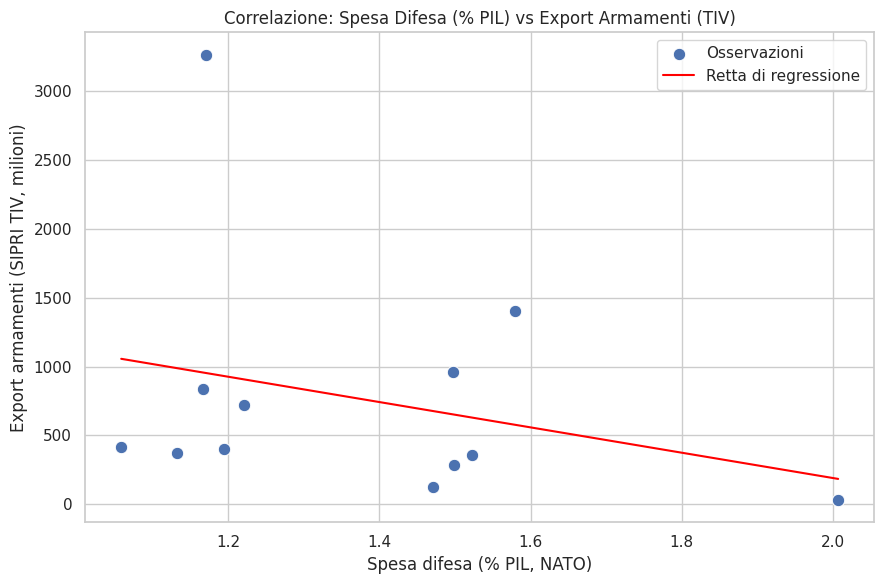

In [ ]:
# Correlazione lineare e regressione: Spesa difesa (% PIL) vs Export TIV
# Usiamo la serie NATO per avere copertura temporale 2014-2025 coerente.
df_merged = pd.merge(
    italy_nato_share[['Year', 'NATO_Share_of_GDP']],
    export_yearly[['Year', 'Export_TIV_Mln']],
    on='Year',
    how='inner'
).dropna()

x = df_merged['NATO_Share_of_GDP']
y = df_merged['Export_TIV_Mln']

slope, intercept, r_value, p_value, std_err = linregress(x, y)

print(f"Osservazioni usate: {len(df_merged)}")
print(f"Coefficiente di correlazione lineare (r): {r_value:.3f}")
print(f"R^2: {r_value**2:.3f}")
print(f"Retta stimata: Export_TIV_Mln = {slope:.3f} * NATO_Share_of_GDP + {intercept:.3f}")
print(f"p-value: {p_value:.4f}")

plt.figure(figsize=(9, 6))
sns.scatterplot(data=df_merged, x='NATO_Share_of_GDP', y='Export_TIV_Mln', s=80, label='Osservazioni')

x_line = np.linspace(x.min(), x.max(), 100)
y_line = intercept + slope * x_line
plt.plot(x_line, y_line, color='red', label='Retta di regressione')

plt.title('Correlazione: Spesa Difesa (% PIL) vs Export Armamenti (TIV)')
plt.xlabel('Spesa difesa (% PIL, NATO)')
plt.ylabel('Export armamenti (SIPRI TIV, milioni)')
plt.legend()
plt.tight_layout()
plt.show()

### Analisi del grafico di correlazione e regressione

Dai risultati ottenuti:

- **r = -0.284**: correlazione lineare negativa ma debole.
- **$R^2 = 0.080$**: la variabilità dell'export spiegata dalla sola % PIL difesa è molto bassa.
- **p-value = 0.3719**: relazione non statisticamente significativa ai livelli convenzionali.

Interpretazione tecnica:
1. Non emerge evidenza di una relazione lineare robusta tra aumento della quota di PIL in difesa e aumento dell'export nel periodo osservato.
2. L'export armamenti sembra essere guidato più da fattori di domanda estera, contratti specifici e dinamiche geopolitiche che dalla sola spesa interna.
3. La regressione lineare semplice è utile come primo test, ma per una spiegazione causale servirebbe un modello multivariato (variabili macro, conflitti, alleanze, cicli industriali).

## 6. Conclusioni finali (stile Data Analyst)

### 3 evidenze data-driven

1. **Convergenza recente verso la soglia NATO**
Nel confronto storico, l'Italia ha mantenuto a lungo una quota difesa/PIL inferiore al 2%; nella parte più recente della serie, il dato mostra un'accelerazione e un avvicinamento deciso alla soglia NATO.

2. **La composizione della spesa conta quanto il livello totale**
L'analisi per componenti segnala un bilancio ancora influenzato dal peso del personale, con una crescita degli investimenti/equipment negli anni più recenti. Questo è un punto centrale perché la capacità militare futura dipende più dalla composizione che dal solo aumento aggregato.

3. **Export armamenti con elevata volatilità e logica per commesse**
La serie export presenta picchi e cadute marcate: il comportamento è tipico di un mercato guidato da grandi contratti e cicli geopolitici, non da una dinamica lineare e stabile.

### Sintesi statistica sulla relazione tra indicatori
La regressione lineare tra spesa difesa (% PIL) ed export TIV non fornisce una relazione forte o statisticamente significativa (r debole, $R^2$ basso, p-value elevato). In termini analitici: la variazione dell'export non è spiegata in modo soddisfacente dalla sola spesa difesa interna.

### Limiti del modello e miglioramenti possibili
- Le due fonti (SIPRI/NATO) hanno definizioni e perimetri non perfettamente identici.
- Le serie annuali sono sensibili a outlier da grandi consegne.
- Una spiegazione più robusta richiede modelli multivariati e variabili di contesto internazionale.

### Riflessione civica (supportata dai dati)
I dati mostrano che il principio costituzionale del ripudio della guerra convive, nella pratica, con un ruolo attivo dell'Italia nella difesa collettiva e nel commercio internazionale di armamenti regolato dalla Legge 185/90. La questione civica non è riducibile a slogan: riguarda come bilanciare sicurezza, trasparenza democratica, responsabilità internazionale e coerenza con i valori costituzionali.